# DDPM代码复现

>参考论文Denoising Diffusion Probabilistic Models

In [61]:
# coding:utf-8

import torch
import torch.nn as nn
import copy
import torch.nn.functional as F
import torchvision
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

* 本文基于CIFAR-10训练

In [62]:
# load CIFAR-10 dataset

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 缩放到[-1, 1]范围
])

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [63]:
# choose one type of data to train
target_class = 'ship'  # 选择要训练的类别
target_class_index = classes.index(target_class)  # 获取类别索引
print(f"Training on class: {target_class} (index: {target_class_index})")

class_indices = [i for i, label in enumerate(dataset.targets) if label == target_class_index]
subset = torch.utils.data.Subset(dataset, class_indices)
subset_dataloader = DataLoader(subset, batch_size=64, shuffle=True)
print(f"Number of samples for class '{target_class}': {len(subset)}")
print("shape of images:", subset[0][0].shape)  # 打印一张图像的形状

Training on class: ship (index: 8)
Number of samples for class 'ship': 5000
shape of images: torch.Size([3, 32, 32])


## 进行数据计算给出beta

* 在DDPM paper中，beta是一个线性增长的Tensor，从beta_1到beta_t总共经过T=1000 steps，同时alpha = 1 - beta，这意味着可以通过一个linspace直接给出beta和alpha的tensor

* 同时，由于$ \overline{\alpha_t} = \prod_{s=1}^{T}{\alpha_s} $，我在计算beta的同时也会给出$ \overline{\alpha_t} $的计算函数

In [64]:
beta_1 = 10e-4
beta_t = 0.02
T = 1000

betas = torch.linspace(beta_1, beta_t, T)  # 线性增加的beta值
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def prod_alpha_t(t):
    # 兼容标量 t 或批量 t，t 取值范围为 [1, T]
    if not torch.is_tensor(t):
        t = torch.tensor(t, dtype=torch.long)
    t = t.long()

    if t.dim() == 0:
        t_idx = torch.clamp(t - 1, 0, T - 1)
        return alpha_bars.to(t.device)[t_idx]

    t_idx = torch.clamp(t - 1, 0, T - 1)
    return alpha_bars.to(t.device)[t_idx]

## 加噪，利用时间步进行，加噪公式如DDPM论文中

DDPM 加噪（前向扩散）公式：

$$
q(\mathbf{x}_t \mid \mathbf{x}_{t-1})=\mathcal{N}\!\left(\mathbf{x}_t;\sqrt{1-\beta_t}\,\mathbf{x}_{t-1},\beta_t\mathbf{I}\right),\quad t=1,\dots,T
$$

$$
\alpha_t = 1-\beta_t,\qquad \bar{\alpha}_t=\prod_{s=1}^{t}\alpha_s
$$

$$
q(\mathbf{x}_t \mid \mathbf{x}_0)=\mathcal{N}\!\left(\mathbf{x}_t;\sqrt{\bar{\alpha}_t}\,\mathbf{x}_0,\left(1-\bar{\alpha}_t\right)\mathbf{I}\right)
$$

$$
\mathbf{x}_t=\sqrt{\bar{\alpha}_t}\,\mathbf{x}_0+\sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon},\qquad \boldsymbol{\epsilon}\sim\mathcal{N}(\mathbf{0},\mathbf{I})
$$

In [65]:
def add_noise(x0, t):
    # x0: (B, C, H, W), t: (B,) 或标量
    noise = torch.randn_like(x0)  # 生成与输入图像相同形状的高斯噪声

    if not torch.is_tensor(t):
        t = torch.tensor(t, device=x0.device)
    t = t.to(x0.device).long()
    if t.dim() == 0:
        t = t.repeat(x0.size(0))

    alpha_prod = prod_alpha_t(t).to(x0.device).view(-1, 1, 1, 1)
    noisy_image = torch.sqrt(alpha_prod) * x0 + torch.sqrt(1 - alpha_prod) * noise
    return noisy_image, noise

## 去噪，接收神经网络去噪参数

前向扩散定义为：

$$q(x_t\mid x_0)=\mathcal N\!\left(x_t;\sqrt{\bar\alpha_t}x_0,(1-\bar\alpha_t)I\right),
\quad
\alpha_t=1-\beta_t,\quad
\bar\alpha_t=\prod_{s=1}^t\alpha_s$$

DDPM 逆过程单步均值（论文常用写法）：

$$
\mu_\theta(x_t,t)=\frac{1}{\sqrt{\alpha_t}}
\left(
x_t-\frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\,
\epsilon_\theta(x_t,t)
\right)
$$

若忽略采样噪声项（只取均值）：

$$
x_{t-1}\approx
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t-\frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\,
\epsilon_\theta(x_t,t)
\right)
$$

因此代码中的核心项
$$
x_t-\frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta
$$
正是逆过程均值公式中的“去噪修正项”。

In [66]:
# 单步去噪，使用DDPM采样公式（带随机项）
def eliminate_noise(xt, t, noise_pred, add_random_noise=True):
    # xt/noise_pred: (B, C, H, W), t: (B,) 或标量，且范围 [1, T]
    if not torch.is_tensor(t):
        t = torch.tensor(t, device=xt.device)
    t = t.to(xt.device).long()
    if t.dim() == 0:
        t = t.repeat(xt.size(0))

    t_idx = torch.clamp(t - 1, 0, T - 1)
    alpha_t = alphas.to(xt.device)[t_idx].view(-1, 1, 1, 1)
    alpha_bar_t = alpha_bars.to(xt.device)[t_idx].view(-1, 1, 1, 1)
    beta_t = betas.to(xt.device)[t_idx].view(-1, 1, 1, 1)

    mean = (xt - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * noise_pred) / torch.sqrt(alpha_t)

    # t>1 时加入随机噪声，避免采样塌缩成单一颜色块
    if add_random_noise:
        noise = torch.randn_like(xt)
        nonzero_mask = (t > 1).float().view(-1, 1, 1, 1)
        xt_prev = mean + nonzero_mask * torch.sqrt(beta_t) * noise
    else:
        xt_prev = mean

    return xt_prev

## Transformer sinusoidal position embedding

>Transformer 位置编码

* 正弦和余弦位置编码，实际上是根据时间码t来给出编码的，这个编码会在UNet里被加入数据中，以告诉神经网络当前的位置

In [67]:
def time_embedding(t, embid_dim):
    # 支持标量时间步或批量时间步输入
    if not torch.is_tensor(t):
        t = torch.tensor(t, dtype=torch.float32)
    t = t.float()
    if t.dim() == 0:
        t = t.unsqueeze(0)
    if t.dim() == 1:
        t = t.unsqueeze(1)  # (B, 1)

    half_dim = embid_dim // 2
    device = t.device
    dtype = t.dtype

    freq = torch.arange(half_dim, device=device, dtype=dtype)
    freq = torch.exp(-torch.log(torch.tensor(10000.0, device=device, dtype=dtype)) * freq / max(half_dim - 1, 1))

    emb = t * freq.unsqueeze(0)
    emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)

    if embid_dim % 2 == 1:
        emb = F.pad(emb, (0, 1))

    return emb  # (B, embid_dim)

## U-Net

* 预测噪声
* 残差网络、池化、反向去噪

In [68]:
class ResNet(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim=32):
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act = nn.SiLU()

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )

        self.shortcut = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.act(h)

        # 在残差块内部注入时间条件
        t_out = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + t_out

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)

        return h + self.shortcut(x)

In [69]:
# 一个容量更大的UNet

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_channels=64, time_emb=time_embedding, time_emb_dim=32):
        super(UNet, self).__init__()
        self.time_embedding = time_emb
        self.time_emb_dim = time_emb_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim * 4)
        )

        # 下采样
        self.down1 = ResNet(in_channels, base_channels, time_emb_dim * 4)
        self.down2 = ResNet(base_channels, base_channels * 2, time_emb_dim * 4)
        self.down3 = ResNet(base_channels * 2, base_channels * 4, time_emb_dim * 4)
        self.down4 = ResNet(base_channels * 4, base_channels * 8, time_emb_dim * 4)
        self.down5 = ResNet(base_channels * 8, base_channels * 16, time_emb_dim * 4)
        self.pool = nn.MaxPool2d(2)
        # 中间层
        self.mid = ResNet(base_channels * 16, base_channels * 16, time_emb_dim * 4)
        self.mid2 = ResNet(base_channels * 16, base_channels * 8, time_emb_dim * 4)

        # 上采样
        self.up1 = ResNet(base_channels * 24, base_channels * 8, time_emb_dim * 4)
        self.up2 = ResNet(base_channels * 16, base_channels * 4, time_emb_dim * 4)
        self.up3 = ResNet(base_channels * 8, base_channels * 2, time_emb_dim * 4)
        self.up4 = ResNet(base_channels * 4, base_channels, time_emb_dim * 4)
        self.up5 = ResNet(base_channels * 2, base_channels, time_emb_dim * 4)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

        self.final_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_embedding(t, self.time_emb_dim)
        t_emb = self.time_mlp(t_emb)

        d1 = self.down1(x, t_emb)
        p1 = self.pool(d1)

        d2 = self.down2(p1, t_emb)
        p2 = self.pool(d2)

        d3 = self.down3(p2, t_emb)
        p3 = self.pool(d3)

        d4 = self.down4(p3, t_emb)
        p4 = self.pool(d4)

        d5 = self.down5(p4, t_emb)

        mid = self.mid(d5, t_emb)
        mid2 = self.mid2(mid, t_emb)

        up1 = self.up1(torch.cat([mid2, d5], dim=1), t_emb)
        up1 = self.upsample(up1)

        up2 = self.up2(torch.cat([up1, d4], dim=1), t_emb)
        up2 = self.upsample(up2)

        up3 = self.up3(torch.cat([up2, d3], dim=1), t_emb)
        up3 = self.upsample(up3)

        up4 = self.up4(torch.cat([up3, d2], dim=1), t_emb)
        up4 = self.upsample(up4)

        up5 = self.up5(torch.cat([up4, d1], dim=1), t_emb)

        return self.final_conv(up5)

In [70]:
# class UNet(nn.Module):
#     def __init__(self, in_channels=3, out_channels=3, time_emb=time_embedding, time_emb_dim=32):
#         """in_channels、out_channels为输入、输出的图像通道数(RGB)"""
#         super(UNet, self).__init__()
#         self.time_emb = time_emb
#         self.time_emb_dim = time_emb_dim

#         self.time_proj = nn.Sequential(
#             nn.Linear(time_emb_dim, time_emb_dim * 4),
#             nn.SiLU(),
#             nn.Linear(time_emb_dim * 4, time_emb_dim)
#         )

#         # down path
#         self.down1 = ResNet(in_channels, 128, time_emb_dim)
#         self.pool1 = nn.MaxPool2d(2)
#         self.down2 = ResNet(128, 256, time_emb_dim)
#         self.pool2 = nn.MaxPool2d(2)

#         self.mid = ResNet(256, 256, time_emb_dim)

#         # up path + skip connection
#         self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
#         self.up_block1 = ResNet(256 + 256, 128, time_emb_dim)
#         self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
#         self.up_block2 = ResNet(128 + 128, 64, time_emb_dim)

#         self.out = nn.Conv2d(64, out_channels, kernel_size=1)

#     def forward(self, x, t):
#         # 统一时间步为 (B, 1) 形状
#         if not torch.is_tensor(t):
#             t = torch.tensor(t, device=x.device, dtype=torch.float32)
#         t = t.to(x.device).float()
#         if t.dim() == 0:
#             t = t.unsqueeze(0)
#         if t.size(0) == 1 and x.size(0) > 1:
#             t = t.repeat(x.size(0))

#         t_emb = self.time_emb(t, self.time_emb_dim)
#         t_emb = self.time_proj(t_emb)

#         s1 = self.down1(x, t_emb)
#         d1 = self.pool1(s1)

#         s2 = self.down2(d1, t_emb)
#         d2 = self.pool2(s2)

#         m = self.mid(d2, t_emb)

#         u1 = self.up1(m)
#         u1 = torch.cat([u1, s2], dim=1)
#         u1 = self.up_block1(u1, t_emb)

#         u2 = self.up2(u1)
#         u2 = torch.cat([u2, s1], dim=1)
#         u2 = self.up_block2(u2, t_emb)

#         return self.out(u2)

Epoch [1/250], Loss: 0.2884
Epoch [2/250], Loss: 0.0826
Epoch [3/250], Loss: 0.0549
Epoch [4/250], Loss: 0.0493
Epoch [5/250], Loss: 0.0415
Epoch [6/250], Loss: 0.0402
Epoch [7/250], Loss: 0.0359
Epoch [8/250], Loss: 0.0356
Epoch [9/250], Loss: 0.0354
Epoch [10/250], Loss: 0.0328
Epoch [11/250], Loss: 0.0321
Epoch [12/250], Loss: 0.0315
Epoch [13/250], Loss: 0.0315
Epoch [14/250], Loss: 0.0304
Epoch [15/250], Loss: 0.0309
Epoch [16/250], Loss: 0.0293
Epoch [17/250], Loss: 0.0285
Epoch [18/250], Loss: 0.0289
Epoch [19/250], Loss: 0.0288
Epoch [20/250], Loss: 0.0291
Epoch [21/250], Loss: 0.0282
Epoch [22/250], Loss: 0.0262
Epoch [23/250], Loss: 0.0286
Epoch [24/250], Loss: 0.0268
Epoch [25/250], Loss: 0.0281
Epoch [26/250], Loss: 0.0259
Epoch [27/250], Loss: 0.0259
Epoch [28/250], Loss: 0.0265
Epoch [29/250], Loss: 0.0252
Epoch [30/250], Loss: 0.0258
Epoch [31/250], Loss: 0.0276
Epoch [32/250], Loss: 0.0260
Epoch [33/250], Loss: 0.0261
Epoch [34/250], Loss: 0.0252
Epoch [35/250], Loss: 0

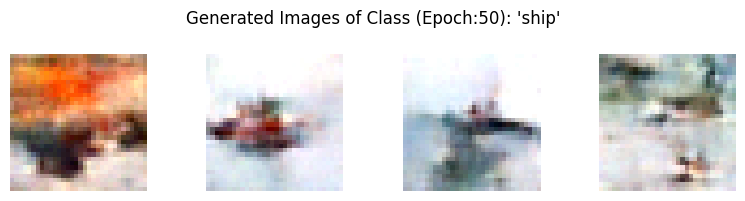

Epoch [51/250], Loss: 0.0235
Epoch [52/250], Loss: 0.0259
Epoch [53/250], Loss: 0.0234
Epoch [54/250], Loss: 0.0239
Epoch [55/250], Loss: 0.0235
Epoch [56/250], Loss: 0.0225
Epoch [57/250], Loss: 0.0238
Epoch [58/250], Loss: 0.0235
Epoch [59/250], Loss: 0.0232
Epoch [60/250], Loss: 0.0233
Epoch [61/250], Loss: 0.0240
Epoch [62/250], Loss: 0.0230
Epoch [63/250], Loss: 0.0226
Epoch [64/250], Loss: 0.0220
Epoch [65/250], Loss: 0.0239
Epoch [66/250], Loss: 0.0232
Epoch [67/250], Loss: 0.0234
Epoch [68/250], Loss: 0.0229
Epoch [69/250], Loss: 0.0254
Epoch [70/250], Loss: 0.0224
Epoch [71/250], Loss: 0.0233
Epoch [72/250], Loss: 0.0231
Epoch [73/250], Loss: 0.0232
Epoch [74/250], Loss: 0.0222
Epoch [75/250], Loss: 0.0217
Epoch [76/250], Loss: 0.0234
Epoch [77/250], Loss: 0.0216
Epoch [78/250], Loss: 0.0221
Epoch [79/250], Loss: 0.0235
Epoch [80/250], Loss: 0.0227
Epoch [81/250], Loss: 0.0223
Epoch [82/250], Loss: 0.0222
Epoch [83/250], Loss: 0.0219
Epoch [84/250], Loss: 0.0215
Epoch [85/250]

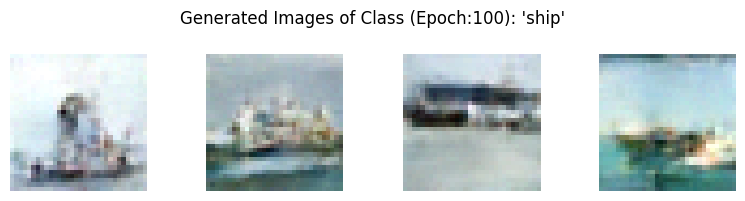

Epoch [101/250], Loss: 0.0216
Epoch [102/250], Loss: 0.0217
Epoch [103/250], Loss: 0.0216
Epoch [104/250], Loss: 0.0222
Epoch [105/250], Loss: 0.0212
Epoch [106/250], Loss: 0.0227
Epoch [107/250], Loss: 0.0217
Epoch [108/250], Loss: 0.0219
Epoch [109/250], Loss: 0.0219
Epoch [110/250], Loss: 0.0213
Epoch [111/250], Loss: 0.0215
Epoch [112/250], Loss: 0.0218
Epoch [113/250], Loss: 0.0220
Epoch [114/250], Loss: 0.0205
Epoch [115/250], Loss: 0.0217
Epoch [116/250], Loss: 0.0211
Epoch [117/250], Loss: 0.0218
Epoch [118/250], Loss: 0.0219
Epoch [119/250], Loss: 0.0216
Epoch [120/250], Loss: 0.0216
Epoch [121/250], Loss: 0.0213
Epoch [122/250], Loss: 0.0212
Epoch [123/250], Loss: 0.0221
Epoch [124/250], Loss: 0.0208
Epoch [125/250], Loss: 0.0213
Epoch [126/250], Loss: 0.0216
Epoch [127/250], Loss: 0.0209
Epoch [128/250], Loss: 0.0220
Epoch [129/250], Loss: 0.0211
Epoch [130/250], Loss: 0.0207
Epoch [131/250], Loss: 0.0207
Epoch [132/250], Loss: 0.0205
Epoch [133/250], Loss: 0.0198
Epoch [134

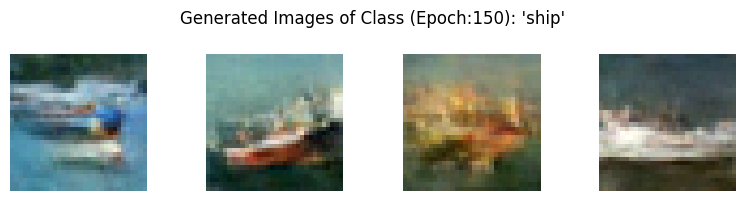

Epoch [151/250], Loss: 0.0195
Epoch [152/250], Loss: 0.0204
Epoch [153/250], Loss: 0.0197
Epoch [154/250], Loss: 0.0206
Epoch [155/250], Loss: 0.0209
Epoch [156/250], Loss: 0.0204
Epoch [157/250], Loss: 0.0205
Epoch [158/250], Loss: 0.0207
Epoch [159/250], Loss: 0.0201
Epoch [160/250], Loss: 0.0203
Epoch [161/250], Loss: 0.0206
Epoch [162/250], Loss: 0.0203
Epoch [163/250], Loss: 0.0201
Epoch [164/250], Loss: 0.0195
Epoch [165/250], Loss: 0.0205
Epoch [166/250], Loss: 0.0192
Epoch [167/250], Loss: 0.0196
Epoch [168/250], Loss: 0.0195
Epoch [169/250], Loss: 0.0199
Epoch [170/250], Loss: 0.0200
Epoch [171/250], Loss: 0.0196
Epoch [172/250], Loss: 0.0189
Epoch [173/250], Loss: 0.0201
Epoch [174/250], Loss: 0.0196
Epoch [175/250], Loss: 0.0197
Epoch [176/250], Loss: 0.0199
Epoch [177/250], Loss: 0.0201
Epoch [178/250], Loss: 0.0202
Epoch [179/250], Loss: 0.0193
Epoch [180/250], Loss: 0.0193
Epoch [181/250], Loss: 0.0204
Epoch [182/250], Loss: 0.0206
Epoch [183/250], Loss: 0.0192
Epoch [184

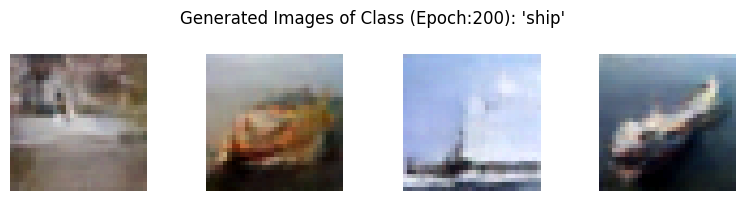

Epoch [201/250], Loss: 0.0197
Epoch [202/250], Loss: 0.0196
Epoch [203/250], Loss: 0.0188
Epoch [204/250], Loss: 0.0197
Epoch [205/250], Loss: 0.0186
Epoch [206/250], Loss: 0.0196
Epoch [207/250], Loss: 0.0187
Epoch [208/250], Loss: 0.0186
Epoch [209/250], Loss: 0.0195
Epoch [210/250], Loss: 0.0193
Epoch [211/250], Loss: 0.0194
Epoch [212/250], Loss: 0.0191
Epoch [213/250], Loss: 0.0187
Epoch [214/250], Loss: 0.0204
Epoch [215/250], Loss: 0.0186
Epoch [216/250], Loss: 0.0189
Epoch [217/250], Loss: 0.0197
Epoch [218/250], Loss: 0.0195
Epoch [219/250], Loss: 0.0199
Epoch [220/250], Loss: 0.0197
Epoch [221/250], Loss: 0.0178
Epoch [222/250], Loss: 0.0199
Epoch [223/250], Loss: 0.0192
Epoch [224/250], Loss: 0.0181
Epoch [225/250], Loss: 0.0191
Epoch [226/250], Loss: 0.0187
Epoch [227/250], Loss: 0.0185
Epoch [228/250], Loss: 0.0187
Epoch [229/250], Loss: 0.0196
Epoch [230/250], Loss: 0.0204
Epoch [231/250], Loss: 0.0199
Epoch [232/250], Loss: 0.0189
Epoch [233/250], Loss: 0.0187
Epoch [234

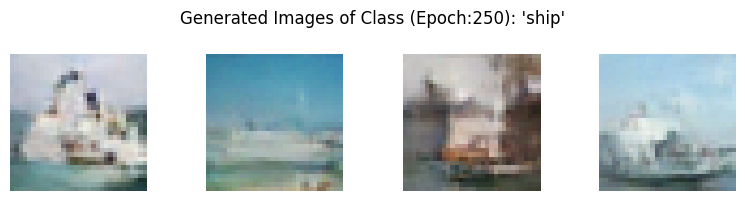

Training completed!


In [71]:
# 训练模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()
num_epochs = 250
warmup_epochs = 5  # warmup 5个 epoch

# show 4 pictures of the target class
def show_sample_images(target_class, epoch=None):
    # make inference
    model.eval()
    with torch.no_grad():
        num_samples = 4
        xt = torch.randn(num_samples, 3, 32, 32).to(device)  # 从纯噪声开始
        for t in range(T, 0, -1):
            t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)
            noise_pred = model(xt, t_batch)
            xt = eliminate_noise(xt, t_batch, noise_pred, add_random_noise=True)

        # 先裁剪到训练归一化范围，再反归一化到 [0, 1]
        xt = torch.clamp(xt, -1.0, 1.0)
        generated_images = ((xt + 1) / 2).clamp(0.0, 1.0).cpu()
        print("Inference completed! Generated images shape (Epoch:{}):".format(epoch), generated_images.shape)

    # 显示生成的图像
    plt.figure(figsize=(8, 2))
    for i in range(num_samples):
        plt.subplot(1, 4, i + 1)
        img = generated_images[i].permute(1, 2, 0).numpy()  # 转换为 HWC 格式
        plt.imshow(np.clip(img, 0.0, 1.0), vmin=0.0, vmax=1.0)
        plt.axis('off')
    plt.suptitle(f"Generated Images of Class (Epoch:{epoch}): '{target_class}'")
    plt.tight_layout()
    plt.show()

def cosine_annealing_with_warmup(step, total_steps=num_epochs, warmup_steps=warmup_epochs, lr_max=1e-4, lr_min=1e-6):
    """Cosine annealing learning rate scheduler with linear warmup."""
    if step < warmup_steps:
        return lr_max
    else:
        # Cosine annealing
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * progress))

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, _ in subset_dataloader:
        images = images.to(device)
        batch_size = images.size(0)
        t = torch.randint(1, T + 1, (batch_size,), device=device)  # 随机时间步
        noisy_images, noise = add_noise(images, t)

        noise_pred = model(noisy_images, t)
        loss = criterion(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_size
    
    lr = cosine_annealing_with_warmup(epoch)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    avg_loss = total_loss / len(subset_dataloader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    if (epoch + 1) % 50 == 0:
        show_sample_images(target_class, epoch=epoch+1)

print("Training completed!")

Inference completed! Generated images shape: torch.Size([16, 3, 32, 32])


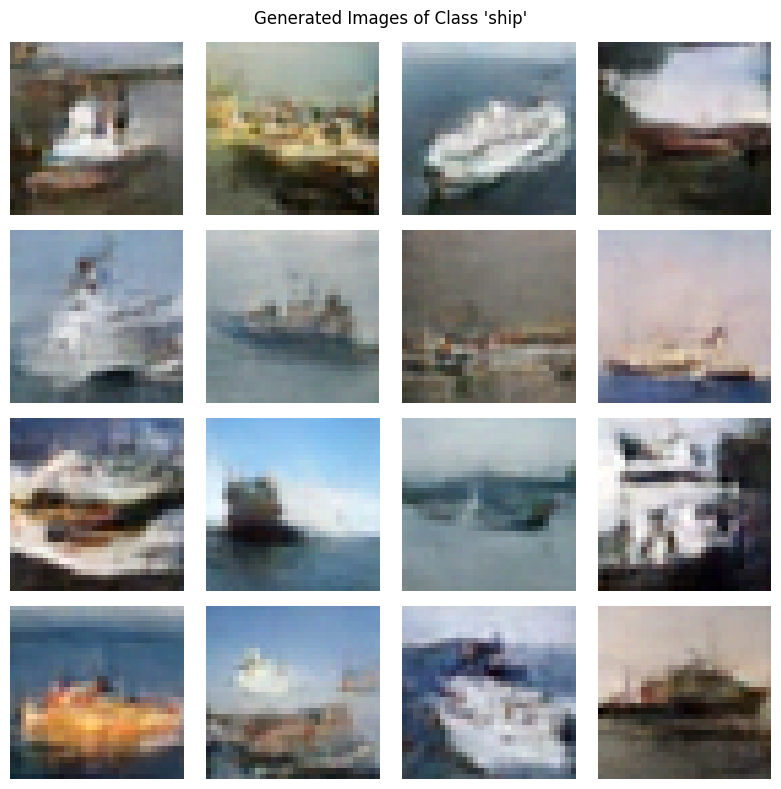

In [72]:
# make inference
model.eval()
with torch.no_grad():
    num_samples = 16
    xt = torch.randn(num_samples, 3, 32, 32).to(device)  # 从纯噪声开始
    for t in range(T, 0, -1):
        t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)
        noise_pred = model(xt, t_batch)
        xt = eliminate_noise(xt, t_batch, noise_pred, add_random_noise=True)

    # 先裁剪到训练归一化范围，再反归一化到 [0, 1]
    xt = torch.clamp(xt, -1.0, 1.0)
    generated_images = ((xt + 1) / 2).clamp(0.0, 1.0).cpu()
    print("Inference completed! Generated images shape:", generated_images.shape)

# 显示生成的图像
plt.figure(figsize=(8, 8))
for i in range(num_samples):
    plt.subplot(4, 4, i + 1)
    img = generated_images[i].permute(1, 2, 0).numpy()  # 转换为 HWC 格式
    plt.imshow(np.clip(img, 0.0, 1.0), vmin=0.0, vmax=1.0)
    plt.axis('off')
plt.suptitle(f"Generated Images of Class '{target_class}'")
plt.tight_layout()
plt.show()

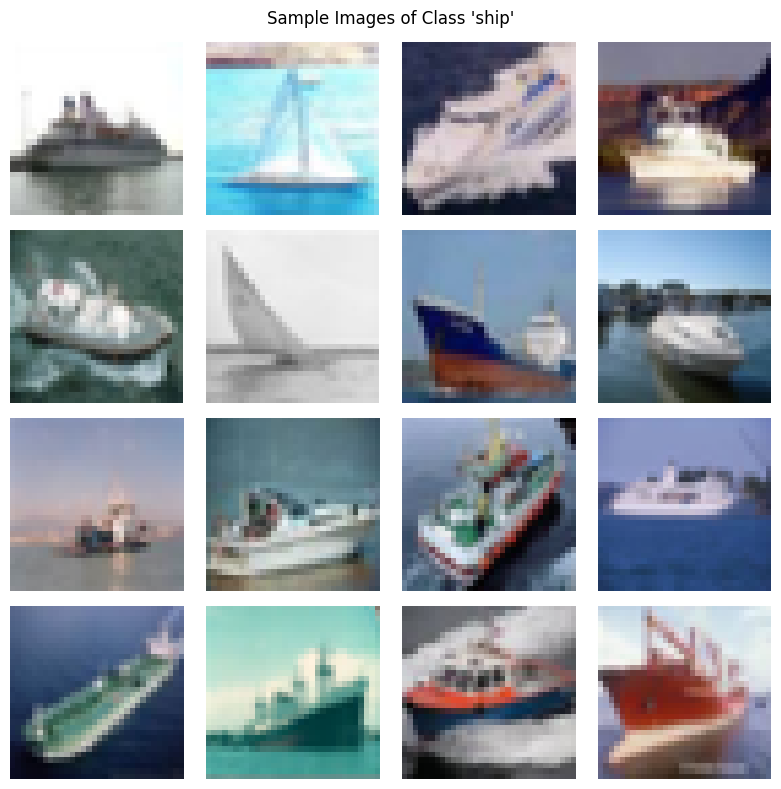

In [73]:
# show 16 pictures of the training data
import random
random_indices = random.sample(range(len(subset)), 16)
subset = torch.utils.data.Subset(subset, random_indices)

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    img = subset[i][0].permute(1, 2, 0).numpy()  # 转换为 HWC 格式
    img = (img * 0.5) + 0.5  # 反归一化到 [0, 1]
    plt.imshow(np.clip(img, 0.0, 1.0), vmin=0.0, vmax=1.0)
    plt.axis('off')

plt.suptitle(f"Sample Images of Class '{target_class}'")
plt.tight_layout()
plt.show()